# Scroll down to "User Input of skills and prediction" and onward for additions  to the project

## This notebook includes the initial model, User Interaction, and an attempt at an improved model.

In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split

In [ ]:
# loading the dataset
df = pd.read_csv("merged ai and job market.csv")

In [ ]:
# removing missing or unknown skills
df = df[df["skills_standardized"].notna()]
df = df[df["skills_standardized"] != "unknown"]

In [ ]:
# splitting skills into a list
df["skills_list"] = df["skills_standardized"].apply(lambda x: x.split(";"))

# frequency analysis
all_skills = [skill for sublist in df["skills_list"] for skill in sublist]

# counting frequency
skill_counts = pd.Series(all_skills).value_counts()

# retrieving unique skills
unique_skills = set(all_skills)
print("Total unique skills:", len(unique_skills))
print(sorted(unique_skills))

Total unique skills: 9
['cloud_computing', 'data_engineering', 'data_visualization', 'deep_learning', 'machine_learning', 'nlp', 'python', 'sql', 'statistics']


In [ ]:
# choosing the top 5 skills to plot
top_n = 5
top_skills = skill_counts.head(top_n)

print("Top Skills:\n", top_skills)

Top Skills:
 cloud_computing     5897
python              5625
machine_learning    5521
sql                 5372
deep_learning       5206
Name: count, dtype: int64


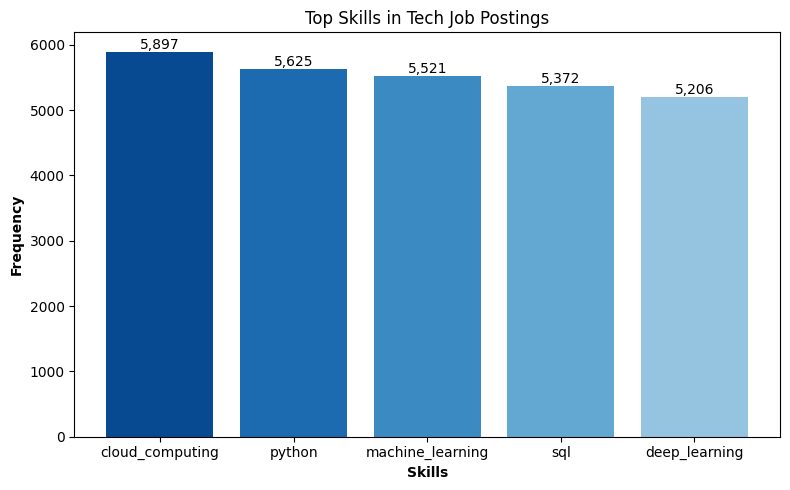

In [ ]:
# creating a visualization
top_n = 5
top_skills = skill_counts.head(top_n)

plt.figure(figsize=(8,5))

# adding gradient colors for a polished plot
colors = cm.Blues(np.linspace(0.9, 0.4, len(top_skills)))

bars = plt.bar(top_skills.index, top_skills.values, color=colors)

# adding labels above each bar for readability
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom')

plt.xlabel("Skills", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')
plt.title("Top Skills in Tech Job Postings")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# TF-IDF for the recommendation system
df["skills_text"] = df["skills_list"].apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df["skills_text"])

# encoding experience
experience_map = {"entry": 0, "mid": 1, "senior": 2}
df["experience_encoded"] = df["experience"].map(experience_map)

# removing missing values
df = df.dropna(subset=["experience_encoded"])

# one-hot encoding categorical features
df_encoded = pd.get_dummies(df[["remote_type", "location"]])

# aligning indices
df_encoded = df_encoded.loc[df.index]

---

In [ ]:
# building feature matrix
X = np.hstack([
    tfidf_matrix.toarray(),
    df["experience_encoded"].values.reshape(-1, 1),
    df_encoded.values])

y = df["salary_usd"].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10866, 199)
y shape: (10866, 1)


In [ ]:
# scaling the target
from sklearn.preprocessing import StandardScaler

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

# splitting into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

In [ ]:
# setting up Pytorch
import torch
import torch.nn as nn
import torch.optim as optim

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
# building the model
class SalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(SalaryModel, self).__init__()

        # defining the neural network structure
        self.model = nn.Sequential(

            # first layer takes input features and maps to 128 neurons
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            # dropout helps prevent overfitting
            nn.Dropout(0.2),

            # second hidden layer reduces complexity
            nn.Linear(128, 64),
            nn.ReLU(),

            # output layer predicts a single value (salary)
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # defining how data flows through the network
        return self.model(x)

# initialize model with number of input features
model = SalaryModel(X_train.shape[1])


In [ ]:
# training the model
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 200

for epoch in range(epochs):
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.9407
Epoch 20, Loss: 0.8022
Epoch 30, Loss: 0.6146
Epoch 40, Loss: 0.5398
Epoch 50, Loss: 0.4950
Epoch 60, Loss: 0.4685
Epoch 70, Loss: 0.4469
Epoch 80, Loss: 0.4348
Epoch 90, Loss: 0.4268
Epoch 100, Loss: 0.4222
Epoch 110, Loss: 0.4125
Epoch 120, Loss: 0.4136
Epoch 130, Loss: 0.4087
Epoch 140, Loss: 0.4019
Epoch 150, Loss: 0.3980
Epoch 160, Loss: 0.3984
Epoch 170, Loss: 0.3946
Epoch 180, Loss: 0.3926
Epoch 190, Loss: 0.3933
Epoch 200, Loss: 0.3889


In [ ]:
# evaluating model
from sklearn.metrics import mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test_tensor).numpy()

# converting back to the original scale
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_test_original, predictions)
r2 = r2_score(y_test_original, predictions)

print("\nNeural Network Results:")
print("MAE:", mae)
print("R²:", r2)


Neural Network Results:
MAE: 19494.982058920767
R²: 0.5870439869066626


# User Input of skills and prediction

Parameters:
    user_skills: list of str (e.g. ["python", "sql", "machine_learning"])
    user_experience:str (e.g. "entry", "mid", "senior")
  

In [ ]:
def predict_salary(user_skills, user_experience):

    # function that takes in a list of skills
    # mapping the sskills and experience as a string
    exp_encoded = experience_map.get(user_experience.lower(), -1)
    if exp_encoded == -1:
        print("Invalid experience level. Choose from: entry, mid, senior")
        return # looking up experience level and error handling

    # TF-IDF transform the user skills that uses same fitted tfidf (100 features)
    user_skills_text = " ".join([s.strip() for s in user_skills])
    # transforms the skills into a (1,100) TFIDF vector using the vectoriser already
    user_tfidf       = tfidf.transform([user_skills_text]).toarray()  # (1, 100)

    # one-hot encoded columns — set all to 0 location/remote (not using them)
    encoded_zeros = np.zeros((1, df_encoded.shape[1]))


    # horizontal stack of the TDIDF vectors which will be the feature vector that X was trained on
    X_user = np.hstack([
        user_tfidf,                   # (1, 100)
        np.array([[exp_encoded]]),    # (1, 1) are the experience values
        encoded_zeros                 # (1, n) are location 0s
    ])

    print("X_user shape:", X_user.shape)  # needs to match X.shape[1]
    print("X shape:",       X.shape[1])

    # scale using fitted scaler_y  but scaler_y was fit on y, not X

    X_user_tensor = torch.tensor(X_user, dtype=torch.float32)

    # prediction
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_user_tensor).numpy()

    # invert the scaler_y to get actual salary and output a salary
    predicted_salary = scaler_y.inverse_transform(pred_scaled)[0][0]

    print(f"\nEstimated Salary: ${predicted_salary:,.0f}")
    print(f"Experience:       {user_experience}")
    print(f"Skills:           {', '.join(user_skills)}")
    print(f"Skill Count:      {len(user_skills)}")


# User Input using these

user_skills     = input("Enter your skills (comma-separated): ").split(",")
user_skills     = [s.strip() for s in user_skills]
user_experience = input("Enter your experience level (entry/mid/senior): ").strip().lower()

predict_salary(user_skills, user_experience)

Enter your skills (comma-separated): python, data cleaning, machine learning, statistic analysis
Enter your experience level (entry/mid/senior): mid
X_user shape: (1, 199)
X shape: 199

Estimated Salary: $137,376
Experience:       mid
Skills:           python, data cleaning, machine learning, statistic analysis
Skill Count:      4


# Attempt Model Improvement

We try a four-layer feedforward neural network built in PyTorch that takes 101 input features: 100 TF-IDF skill tokens and one ordinally encoded experience feature, and progressively compresses them through hidden layers of 128, 64, and 32 neurons before outputting a salary prediction.

Each hidden layer follows a consistent pattern of Linear transformation, Batch Normalization to stabilize activations, ReLU to introduce non-linearity, and Dropout to prevent overfitting. The Dropout decreases across layers from 0.3 to 0.2 and removed entirely before the output to avoid removing  too much information at the final stage.

The model is optimized using AdamW with a learning rate of 0.0001 and weight decay of 0.0001, which was chosen because AdamW decouples regularization from the gradient update for better generalization and the low learning rate prevents the gradient instability. This decoupling means that AdamW separates the weight decay step from the gradient update entirely, applying it directly to the weights after the gradient update as its own independent operation, so the regularization effect stays consistent and predictable regardless of what the adaptive learning rate is doing at that moment.

Both the input features and salary target are scaled using StandardScaler before training, and predictions are inverted using the fitted target scaler at inference time to return an interpretable dollar amount to the user.



In [ ]:
from sklearn.preprocessing import StandardScaler

# scale first bc needed for the neural network since the TF-IDF values and the experience encoding are on different scales
scaler_X = StandardScaler() # use this on the full feature matrix X and transform it to have zero mean and unit variance
X_scaled = scaler_X.fit_transform(X)

#similar reason for y
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# splitting into train and test
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# split train into train and val
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_train_scaled, y_train, test_size=0.1, random_state=42
)

# tensors (converting numpy arrays into pytorch tensors)
X_train_tensor = torch.tensor(X_train_np,    dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_np,      dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np,    dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val_np,      dtype=torch.float32)


In [ ]:

# building the model
class SalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(SalaryModel, self).__init__()
        self.model = nn.Sequential(

            #keep first layer thatmaps 101 input features to 128 neurons
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128), # implement BatchNorm to normalize 128 activations
            nn.ReLU(), # common activation function
            nn.Dropout(0.3), #needed to zero out 30% of neurons

            # second hidden layer which should carry less redundancy
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # third hidden later to compress

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

# initialize model
model = SalaryModel(X_train_scaled.shape[1])

# update the models weights w an optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


In [ ]:

# training loop
criterion = nn.MSELoss()
epochs    = 200

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss    = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_tensor), y_val_tensor).item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}  Train Loss: {loss.item():.4f} Val Loss: {val_loss:.4f}")

# evaluation
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test_tensor).numpy()

predictions     = scaler_y.inverse_transform(predictions_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_test_original, predictions)
r2  = r2_score(y_test_original, predictions)

print("\nNeural Network Results:")
print(f"MAE: ${mae:,.0f}")
print(f"R²:  {r2:.4f}")

Epoch 10  Train Loss: 0.6763 Val Loss: 0.6003
Epoch 20  Train Loss: 0.6634 Val Loss: 0.5761
Epoch 30  Train Loss: 0.6306 Val Loss: 0.5557
Epoch 40  Train Loss: 0.6066 Val Loss: 0.5341
Epoch 50  Train Loss: 0.5877 Val Loss: 0.5125
Epoch 60  Train Loss: 0.5703 Val Loss: 0.4944
Epoch 70  Train Loss: 0.5601 Val Loss: 0.4770
Epoch 80  Train Loss: 0.5392 Val Loss: 0.4632
Epoch 90  Train Loss: 0.5257 Val Loss: 0.4521
Epoch 100  Train Loss: 0.5163 Val Loss: 0.4430
Epoch 110  Train Loss: 0.5039 Val Loss: 0.4366
Epoch 120  Train Loss: 0.4996 Val Loss: 0.4322
Epoch 130  Train Loss: 0.4966 Val Loss: 0.4280
Epoch 140  Train Loss: 0.4972 Val Loss: 0.4257
Epoch 150  Train Loss: 0.4979 Val Loss: 0.4237
Epoch 160  Train Loss: 0.4851 Val Loss: 0.4228
Epoch 170  Train Loss: 0.4804 Val Loss: 0.4219
Epoch 180  Train Loss: 0.4735 Val Loss: 0.4206
Epoch 190  Train Loss: 0.4835 Val Loss: 0.4192
Epoch 200  Train Loss: 0.4715 Val Loss: 0.4189

Neural Network Results:
MAE: $19,995
R²:  0.5551
